In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import h5py

from pipeline.processing.fit_continuum import _powerlaw
from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark
from pipeline.processing.parameters import CIV_AIR, NV_AIR, LYA_AIR

FIT_PARAMS_PATH = "data/fit_params.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"
SPECTRA_PATH = "data/spectra.h5"

In [3]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
fit_params = pd.read_csv(FIT_PARAMS_PATH,index_col=0,dtype={"targetid":"str"})

In [4]:
full = results[(results["z"]>2) & (results["z"]<3.4)]
core_erq = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]

In [5]:
lam_full = []
flux_full = []

In [6]:
for i, idx in enumerate(np.random.choice(full.index,20000)):
    with h5py.File(SPECTRA_PATH, "r") as f:
        data = f[f"{idx}"][()]

        lam = data[0,:]
        flux = data[1,:]

        cont_params = ast.literal_eval(fit_params.loc[idx,"continuum_fit_lya_nv"])["fit_params"]

        cont_flux = _powerlaw(lam/1290,**cont_params)

        lam_full.extend(lam)
        flux_full.extend(flux/cont_flux)

/tmp/ipykernel_497/4044092467.py:13: RuntimeWarning: divide by zero encountered in divide
  flux_full.extend(flux/cont_flux)


In [7]:
lam_core_erq = []
flux_core_erq = []

In [8]:
for idx in core_erq.index:
    with h5py.File(SPECTRA_PATH, "r") as f:
        data = f[f"{idx}"][()]

        lam = data[0,:]
        flux = data[1,:]

        cont_params = ast.literal_eval(fit_params.loc[idx,"continuum_fit_lya_nv"])["fit_params"]

        cont_flux = _powerlaw(lam/1290,**cont_params)

        lam_core_erq.extend(lam)
        flux_core_erq.extend(flux/cont_flux)

/tmp/ipykernel_497/2725202399.py:13: RuntimeWarning: divide by zero encountered in divide
  flux_core_erq.extend(flux/cont_flux)


In [9]:
from scipy.stats import binned_statistic

In [10]:
median_full = binned_statistic(x=lam_full,values=flux_full,statistic="median",bins=(818))
median_core_erq = binned_statistic(x=lam_core_erq,values=flux_core_erq,statistic="median",bins=(818))

In [12]:
with open("data/local/median_full_backup.txt","w") as f:
    f.write(str(median_full))

In [14]:
settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':6.0,
        'xtick.minor.size':4.0,
        'ytick.major.size':6.0,
        'ytick.minor.size':4.0,
        'legend.frameon':False,
    }

plt.rcParams.update(**settings)

[]

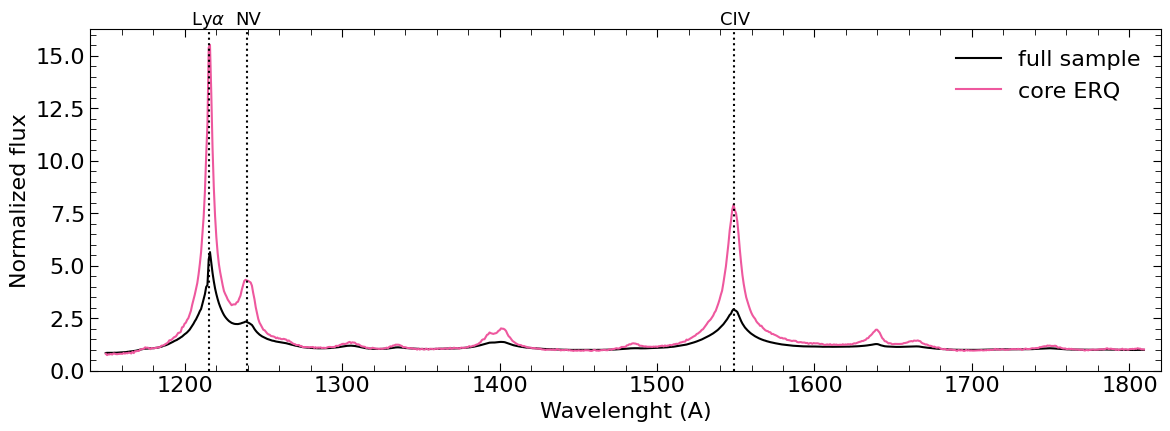

In [41]:
fig, ax = plt.subplots(figsize=(12,4.6))

plt.plot(median_full[1][:-1],median_full[0],color="black",label="full sample")
plt.plot(median_core_erq[1][:-1],median_core_erq[0],label="core ERQ",color=palette_dark[0])

ax.axvline(CIV_AIR,linestyle=":",color="black")
ax.text(1540,16.5,"CIV",fontsize=13)
ax.axvline(NV_AIR,linestyle=":",color="black")
ax.text(1232,16.5,"NV",fontsize=13)
ax.axvline(LYA_AIR,linestyle=":",color="black")
ax.text(1204,16.5,r"Ly$\alpha$",fontsize=13)

plt.legend(loc="upper right")

plt.xlim(1140,1820)

plt.xlabel("Wavelenght (A)")
plt.ylabel("Normalized flux")

plt.tight_layout()

plt.plot()

In [52]:
median_res = binned_statistic(x=list(lam1)+list(lam2),values=list(flux1)+list(flux2),statistic="median",bins=500)

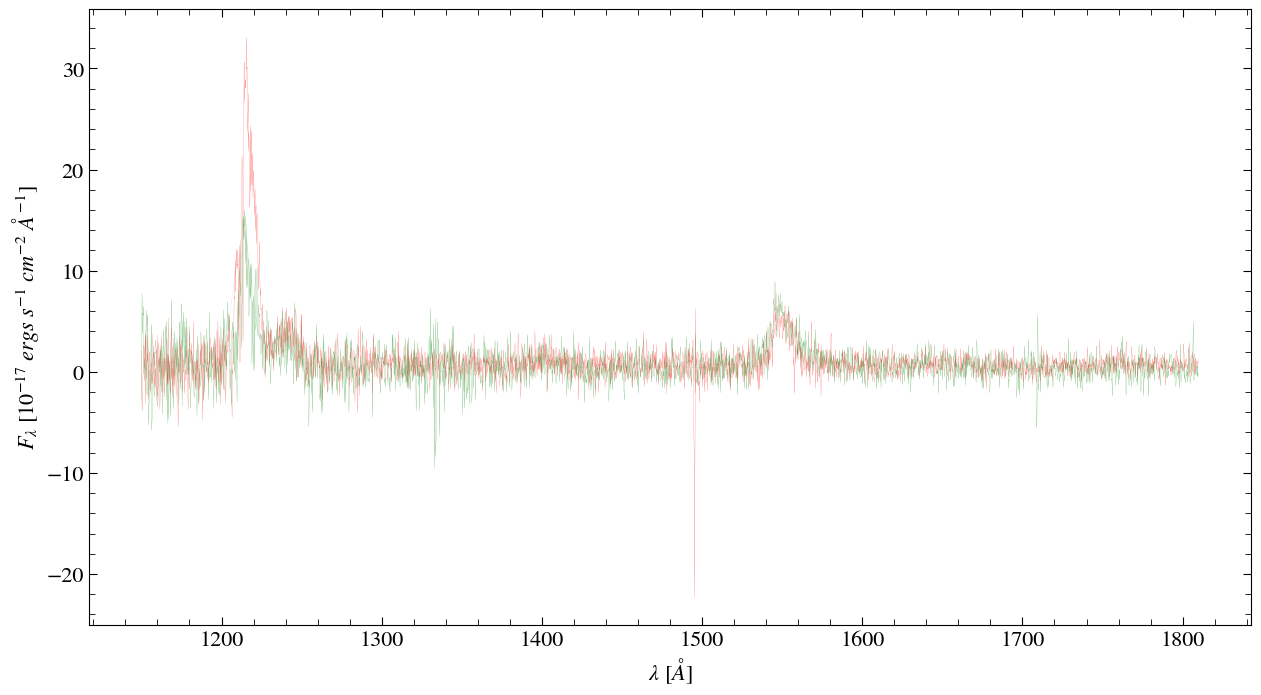

In [44]:
plot_spectrum(lam=median_res[1][:-1],flux=median_res[0],additional_lam=[lam1,lam2],additional_flux=[flux1,flux2],additional_flux_color=["red","green"],line_width_factor=0.1,color="black")